# 1. IMPORT LIBRARIES


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams["figure.figsize"] = (10,6)

c:\Users\tamil\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\tamil\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\Users\tamil\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# 2. READ DATASET

In [2]:
df1 = pd.read_csv('../input/nsl-kdd/KDDTrain+.txt')
df2 = pd.read_csv('../input/nsl-kdd/KDDTest+.txt')



# 2.1 ADJUST COLUMNS

In [3]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
            'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
            'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
            'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
            'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
            'dst_host_srv_rerror_rate','attack','level'])

df1.columns = columns
df2.columns = columns



In [4]:
df2.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.000,0.060,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.610,0.040,0.610,0.020,0.000,0.000,0.000,0.000,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.000,0.000,1.000,0.280,0.000,0.000,0.000,0.000,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.310,0.170,0.030,0.020,0.000,0.000,0.830,0.710,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.000,0.000,0.010,0.030,0.010,0.000,0.000,0.000,normal,21


In [5]:
df1.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21


# 2.2 INSIGHTS

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

We have different types of dtypes, we need encoding, doesn't seem like we have null values but we will check

In [7]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.000,287.147,2604.526,0.000,0.000,0.000,0.000,42908.000
src_bytes,125972.000,45567.101,5870354.481,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125972.000,19779.271,4021285.112,0.000,0.000,0.000,516.000,1309937401.000
land,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125972.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125972.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125972.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125972.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125972.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


There are some outlier values, but we will check if it's too much

# 3. DATA CLEANING

# 3.1 NULL VALUES

In [8]:
df1.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

Dataset doesn't contain any null value

In [6]:
 
def unique_values(df, columns):

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [7]:
cat_features = df1.select_dtypes(include='object').columns
unique_values(df1, cat_features)

Column: protocol_type
------------------------------
Unique Values (3): ['udp' 'tcp' 'icmp']

Value Counts:
protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
------------------------------
Unique Values (70): ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Value Counts:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6859
 

Further analysis will be in EDA-VISAULAZTION part about these column's impacts on Attacks

# 3.2 DUPLICATES

In [8]:
df1.duplicated().sum()

0

Dataset doesn't contain any duplicated row

# 3.3 OUTLIERS

In [9]:
df1.shape

(125972, 43)

<Figure size 2000x4000 with 0 Axes>

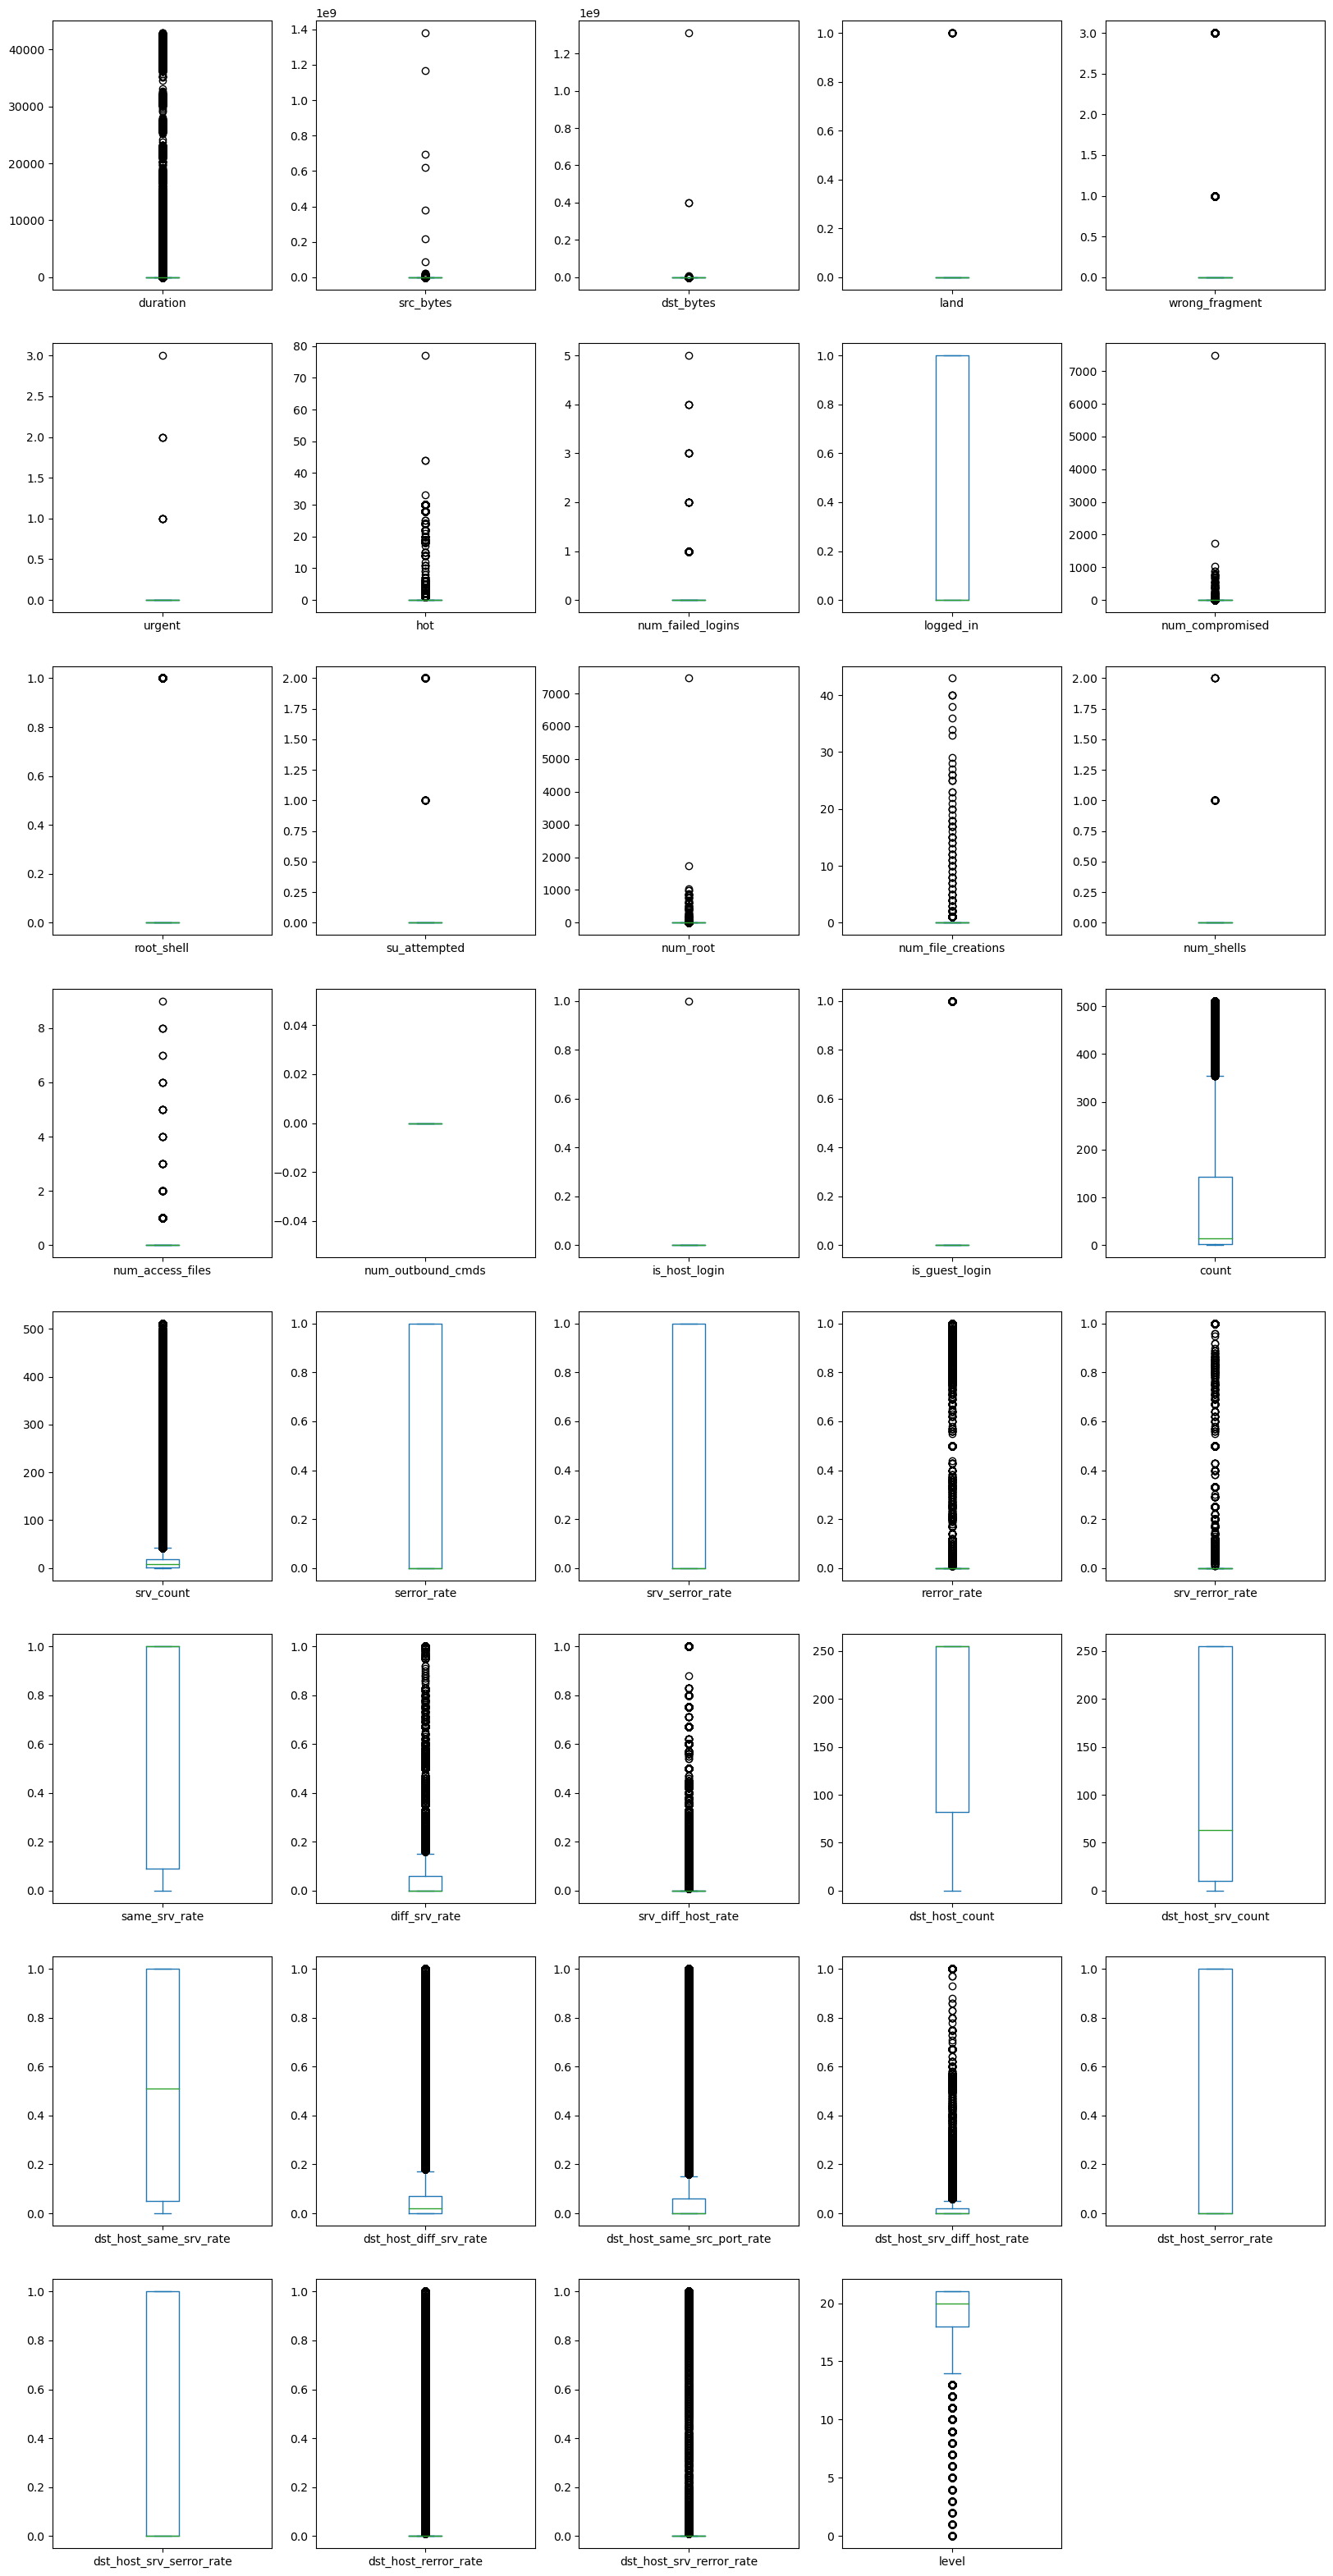

In [12]:
plt.figure(figsize=(20, 40))
df1.plot(kind='box', subplots=True, layout=(8, 5), figsize=(20, 40))
plt.show()

There is no too much outlier to misslead the model so i will not drop the outliers

# 3.4 labeling the class

In [11]:
def change_label(df):
    
    df.attack.replace(
        ['apache2', 'back', 'land', 'neptune', 'mailbomb', 
         'pod', 'processtable', 'smurf', 'teardrop', 
         'udpstorm', 'worm'], 'DoS', inplace=True)
    
    df.attack.replace(
        ['ftp_write', 'guess_passwd', 'httptunnel', 'imap', 
         'multihop', 'named', 'phf', 'sendmail', 
         'snmpgetattack', 'snmpguess', 'spy', 
         'warezclient', 'warezmaster', 'xlock', 'xsnoop'], 'U2R', inplace=True)
    
    df.attack.replace(
        ['ipsweep', 'mscan', 'nmap', 'portsweep', 
         'saint', 'satan'], 'R2L', inplace=True)
    
    df.attack.replace(
        ['buffer_overflow', 'loadmodule', 'perl', 'ps', 
         'rootkit', 'sqlattack', 'xterm'], 'Probe', inplace=True)
    
    df.attack.replace('normal', 'Normal', inplace=True)
 
change_label(df1)
change_label(df2)


In [12]:
df1['attack'].value_counts()

attack
Normal    67342
DoS       45927
R2L       11656
U2R         995
Probe        52
Name: count, dtype: int64

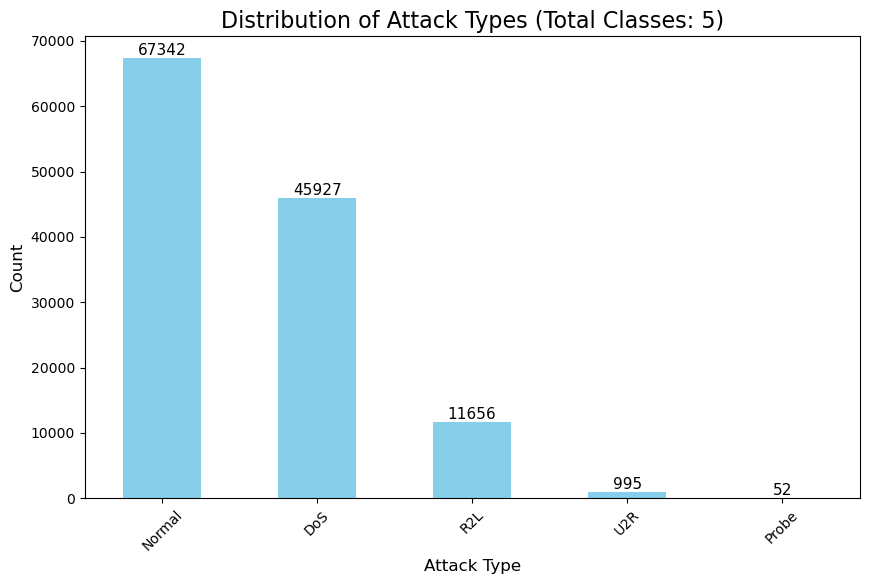

In [15]:
import matplotlib.pyplot as plt

attack_counts = df1['attack'].value_counts()

plt.figure(figsize=(10, 6))
bars = attack_counts.plot(kind='bar', color='skyblue')

for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height())}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                  ha='center', va='bottom', fontsize=11)

num_classes = df1['attack'].nunique()
plt.title(f'Distribution of Attack Types (Total Classes: {num_classes})', fontsize=16)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=45)
plt.show()


In [15]:
df2['attack'].value_counts()

attack
Normal    9711
DoS       7459
U2R       2885
R2L       2421
Probe       67
Name: count, dtype: int64

# 4. EDA - VISUALIZATIONS

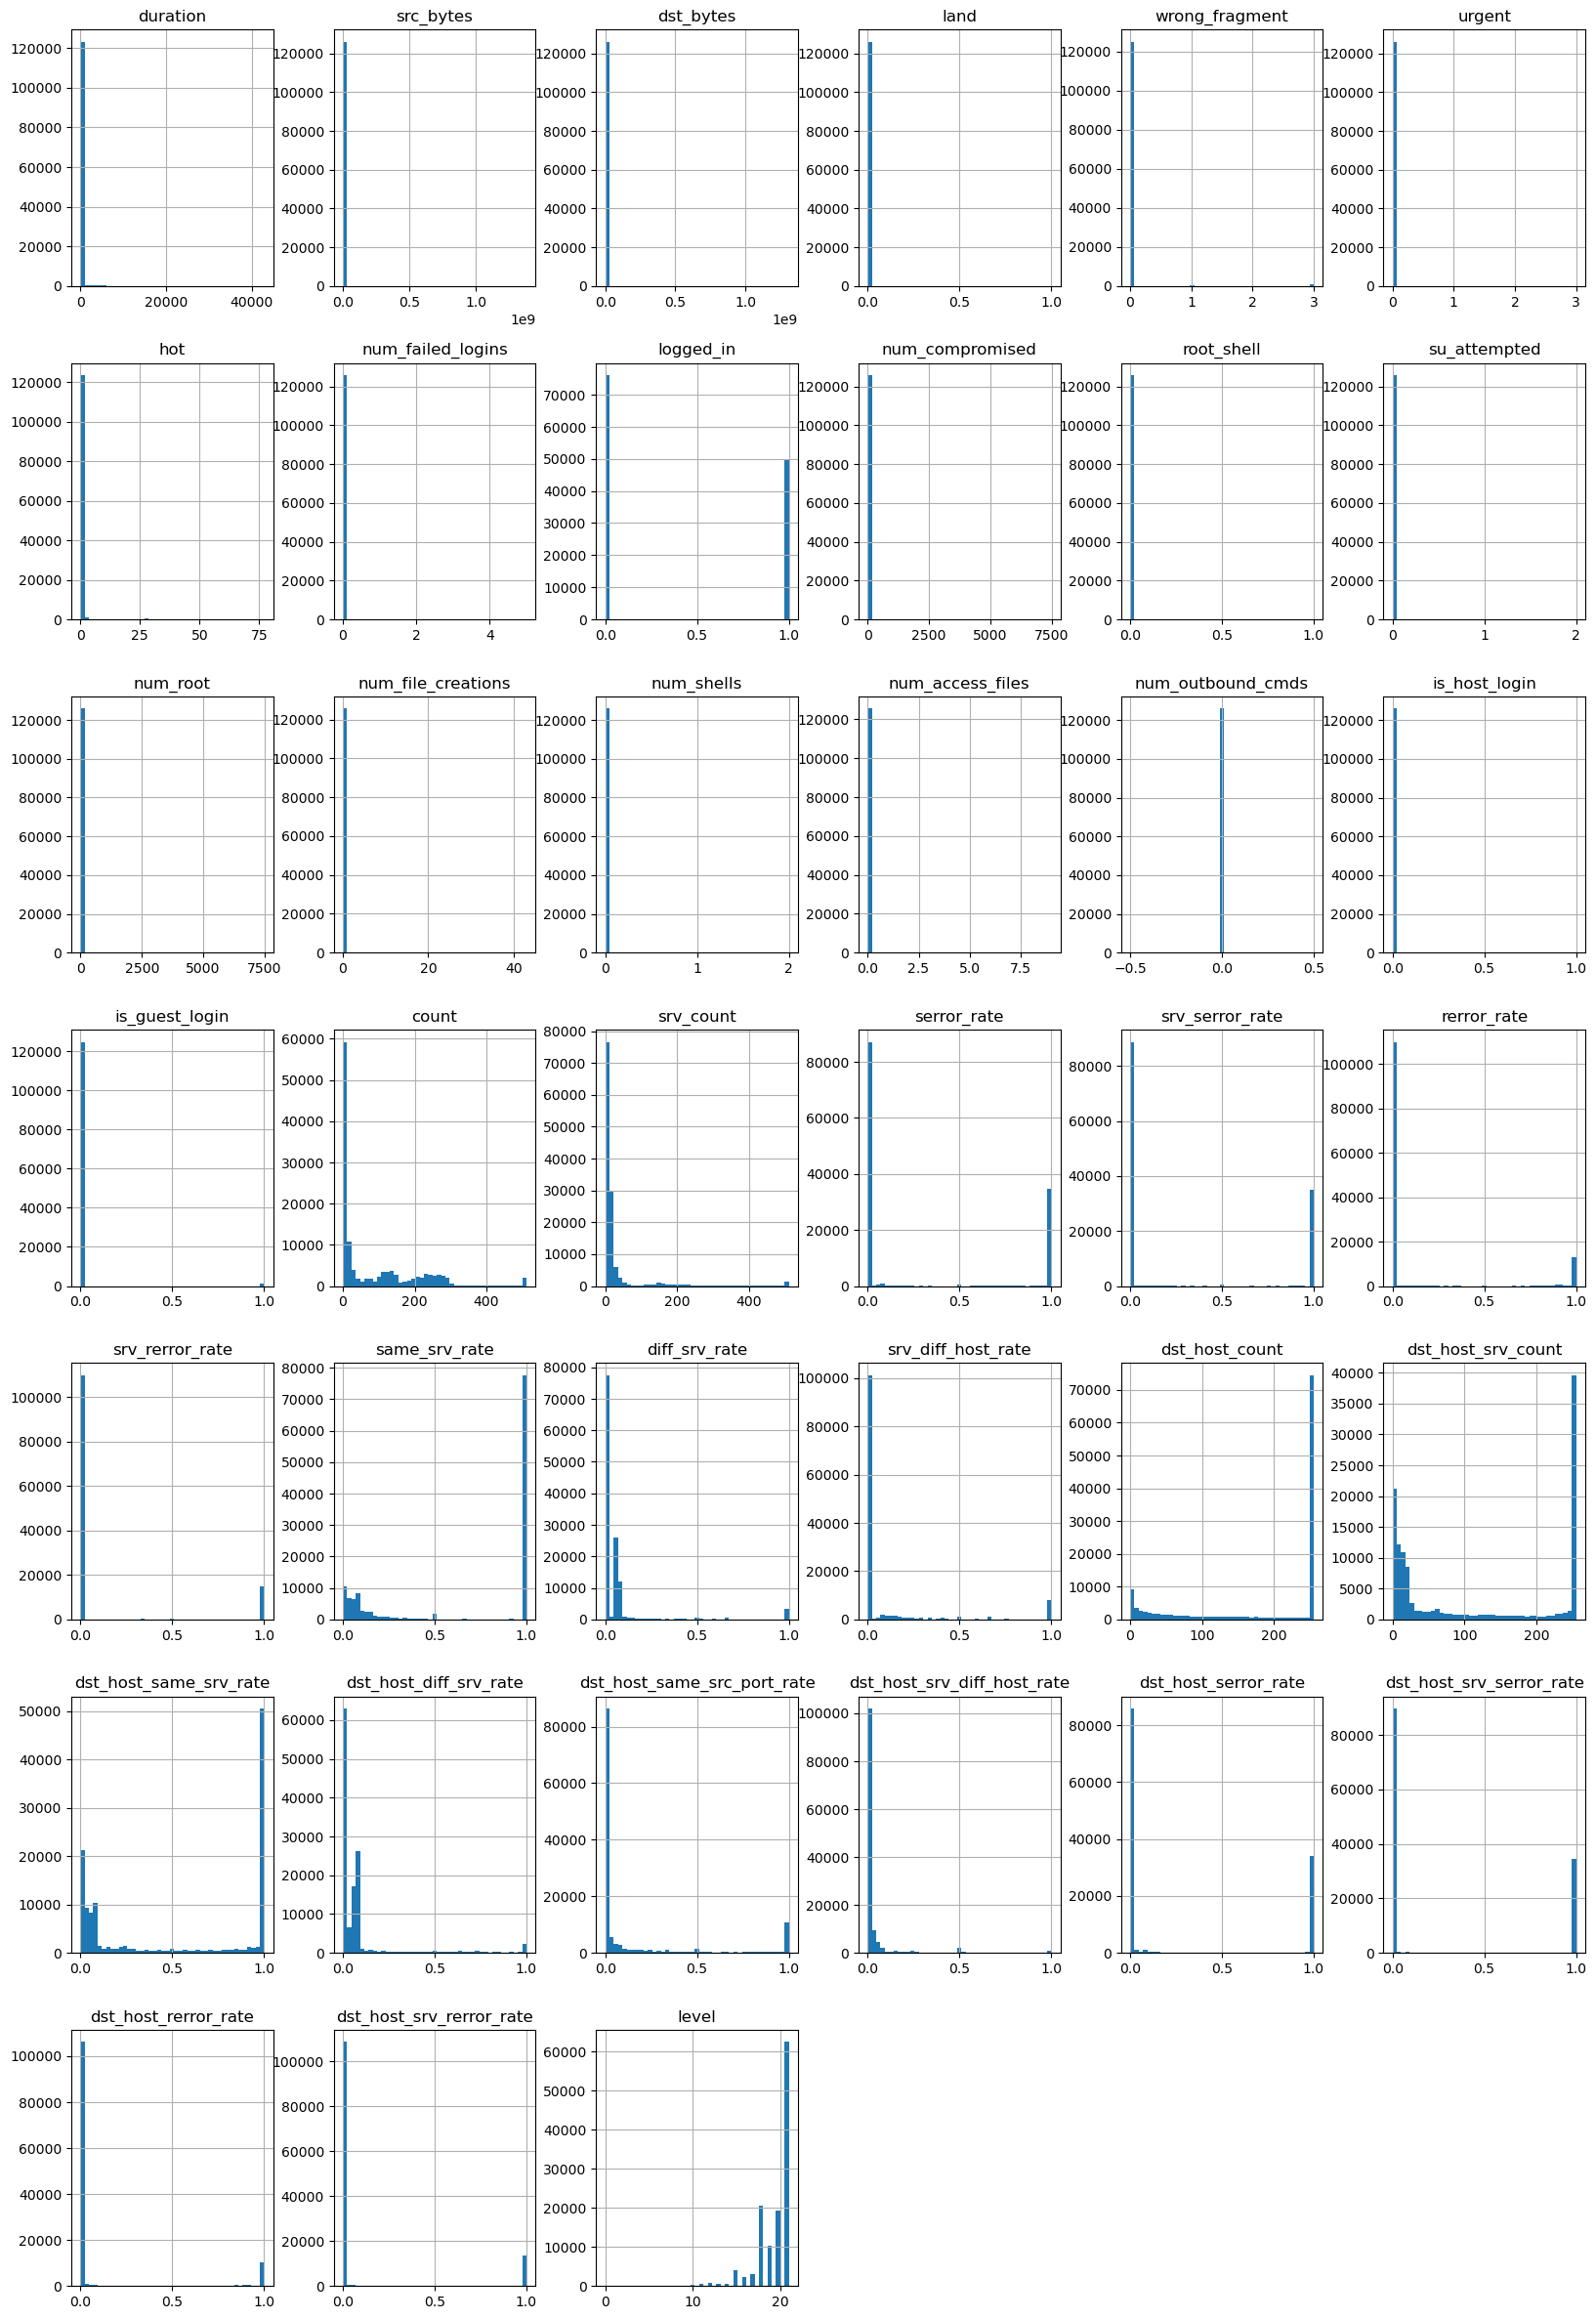

In [17]:
df1.hist(bins=43,figsize=(20,30));

General visualization in order to get insights

# 4.1 Protocol Type

In [18]:
df1["protocol_type"].value_counts(normalize=True)

protocol_type
tcp    0.815
udp    0.119
icmp   0.066
Name: proportion, dtype: float64

### So we can see that most of the attacks are from tcp, then udp, and least attack comes from icmp.

# 4.2 Service used general

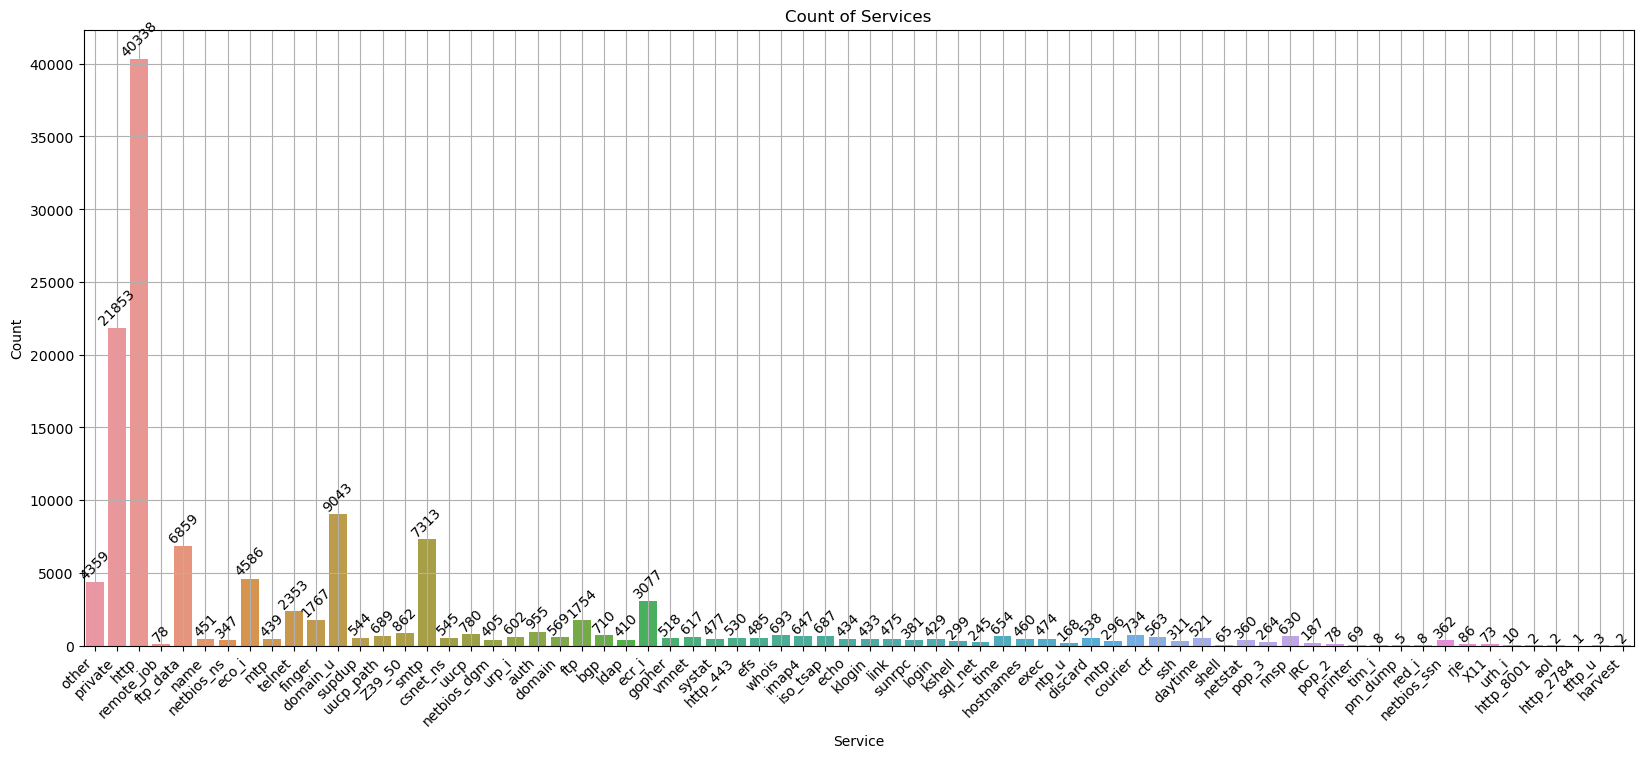

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  
ax = sns.countplot(x='service', data=df1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Count of Services')

for p in ax.patches:
    count_value = int(p.get_height())
    ax.annotate(f'{count_value}', 
                (p.get_x() + p.get_width() / 2., count_value + 1), 
                ha='center', va='bottom', 
                fontsize=10, color='black', 
                rotation=45)  # Rotate the annotation

plt.grid(True)
plt.show()


### Services most used in general follows as, http,private,domain_u,smtp, ftp,other..

# 4.3 Service used effect on attacks

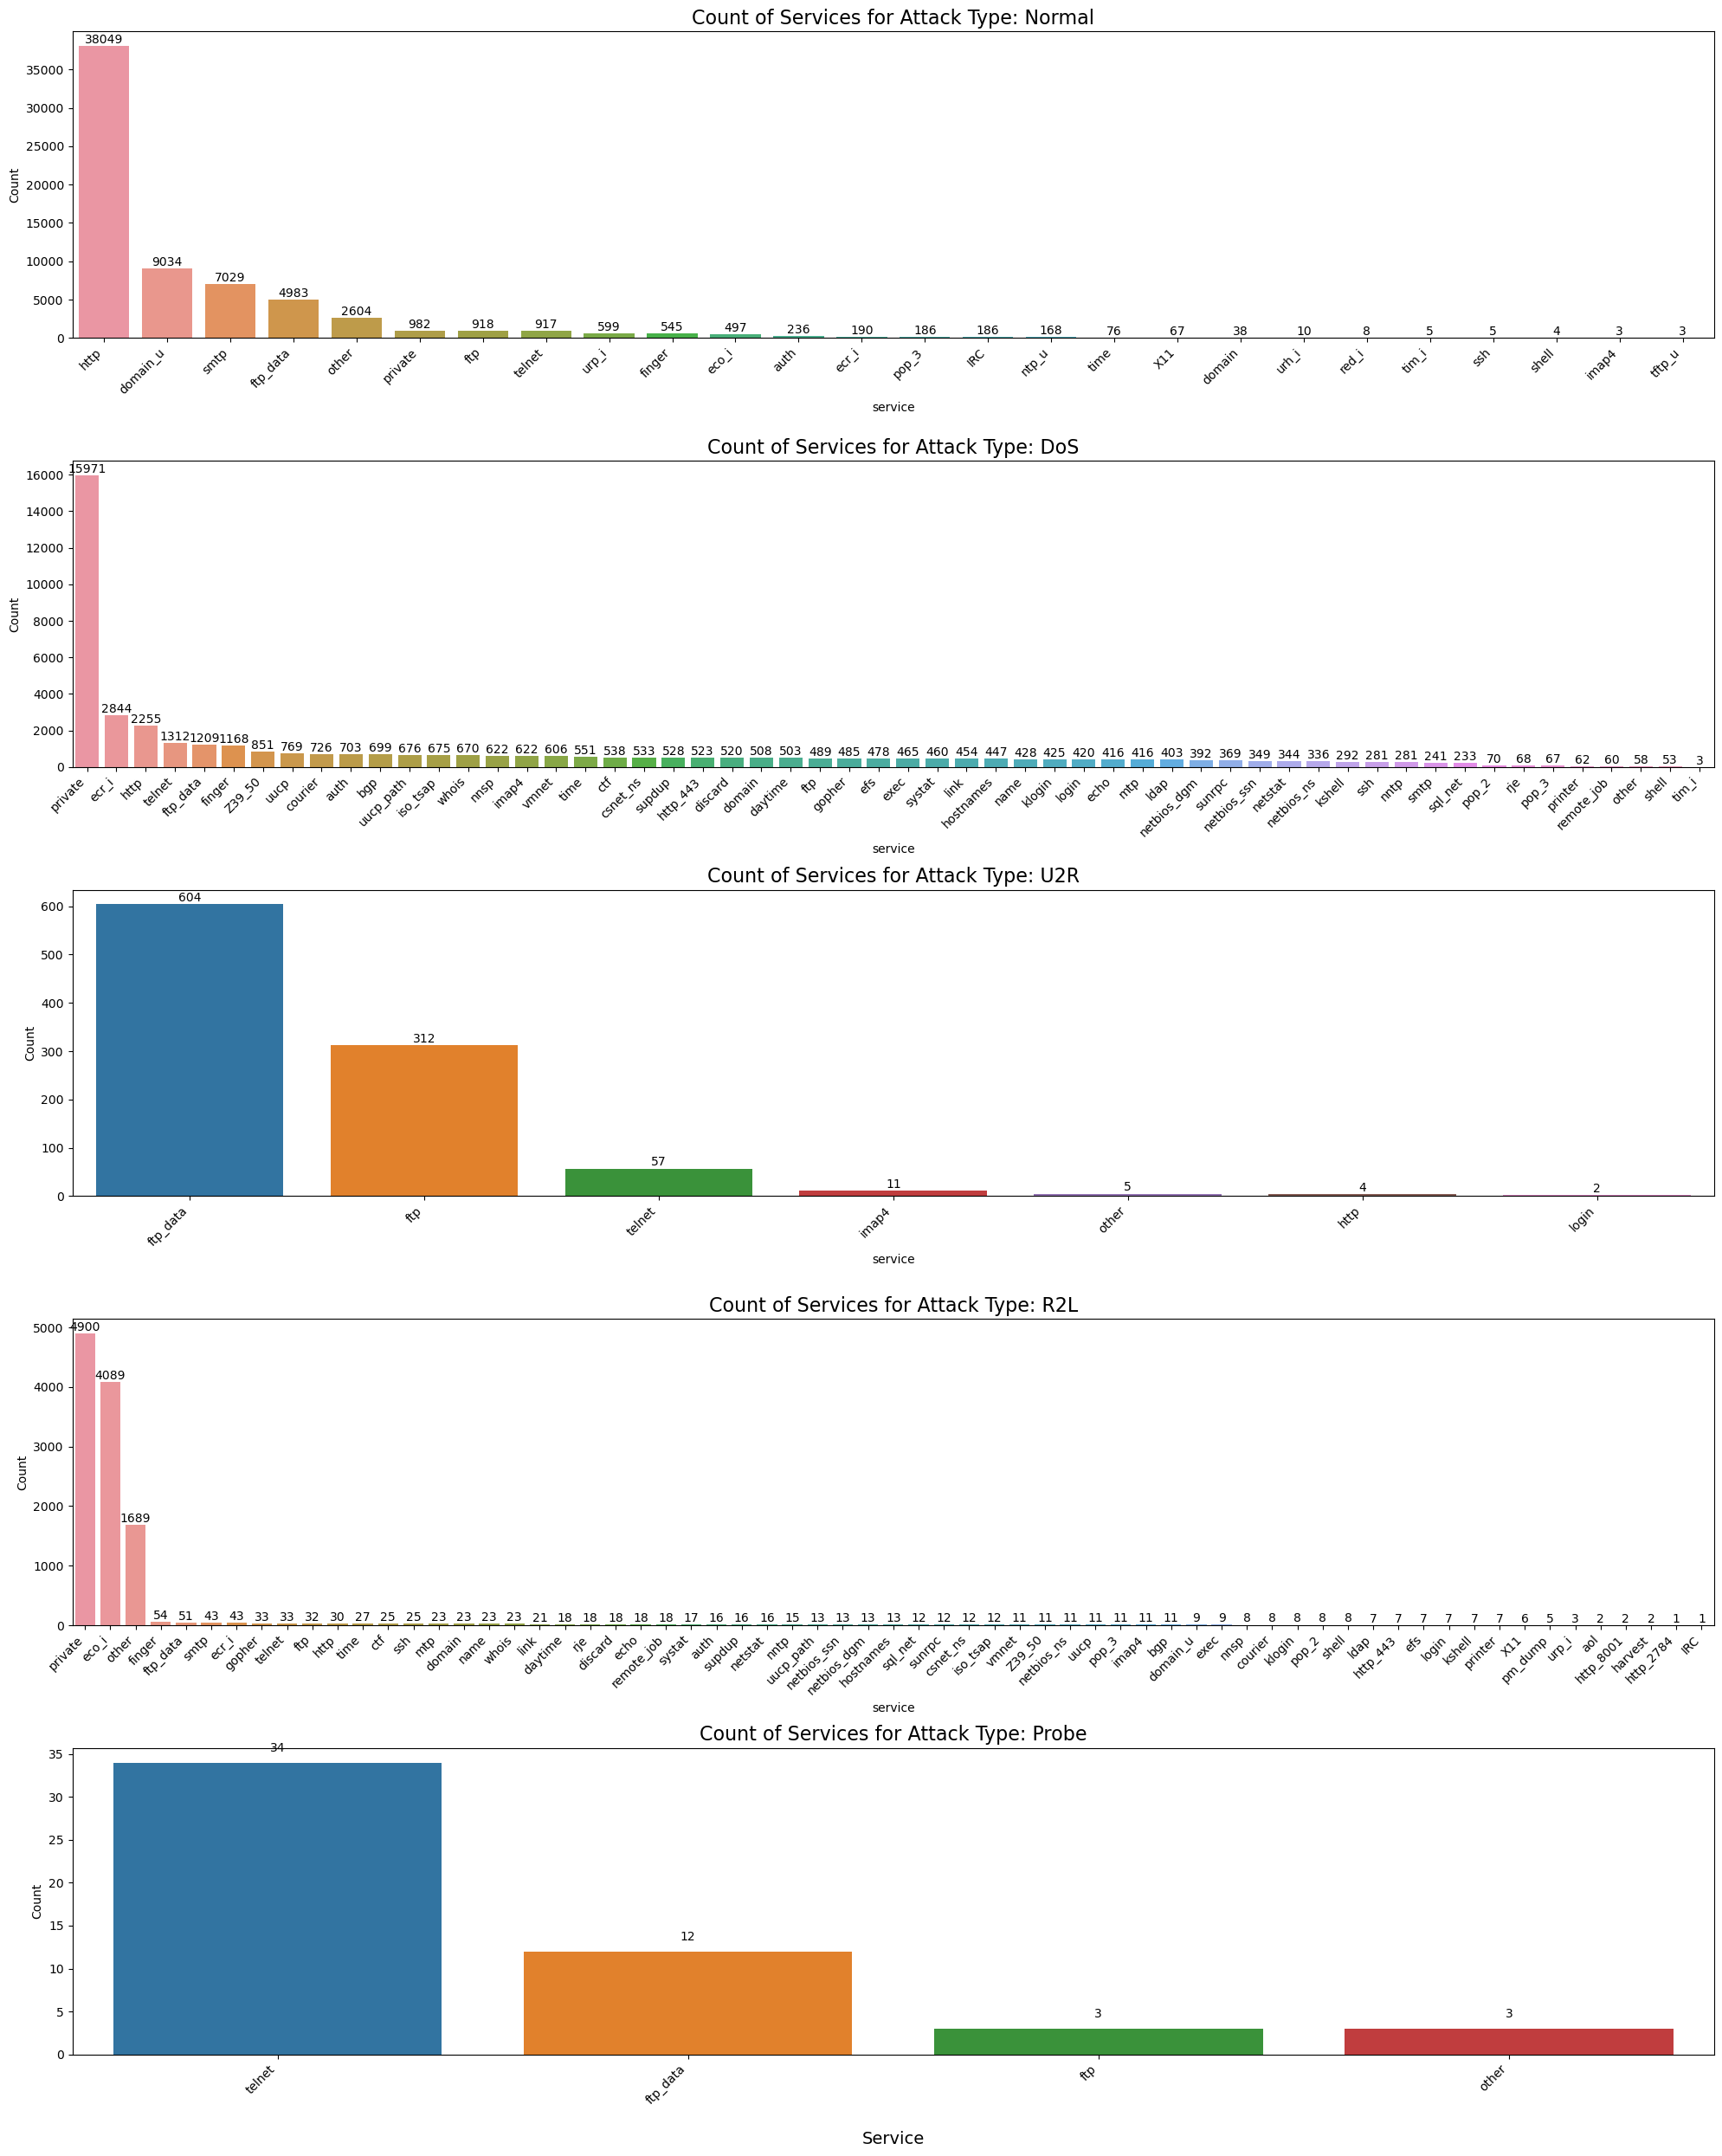

In [20]:

attack_types = df1['attack'].unique()

num_attacks = len(attack_types)
fig, axes = plt.subplots(num_attacks, 1, figsize=(20, 5 * num_attacks))

for i, attack in enumerate(attack_types):
    ax = axes[i]
    subset = df1[df1['attack'] == attack]
    
    sns.countplot(x='service', data=subset, ax=ax, order=subset['service'].value_counts().index)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    
    ax.set_title(f'Count of Services for Attack Type: {attack}', fontsize=16)
    ax.set_ylabel('Count')
    
    for p in ax.patches:
        count_value = int(p.get_height())
        ax.annotate(f'{count_value}', 
                    (p.get_x() + p.get_width() / 2., count_value + 1), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black')

plt.xlabel('Service', fontsize=14, labelpad=20)  

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  
plt.show()



In [16]:
import pandas as pd

attack_service_dict = df1.groupby('attack')['service'].apply(set).to_dict()

for k in attack_service_dict.keys():
    print(k,' : ',attack_service_dict[k])
    
del attack_service_dict['Normal']

intersected_services = set.intersection(*attack_service_dict.values())

print("\n\nThe common services among all attacks" ,intersected_services)


DoS  :  {'link', 'ldap', 'other', 'telnet', 'ssh', 'iso_tsap', 'nnsp', 'printer', 'Z39_50', 'smtp', 'ftp_data', 'ftp', 'time', 'whois', 'systat', 'name', 'uucp', 'sql_net', 'netstat', 'auth', 'csnet_ns', 'netbios_ns', 'courier', 'supdup', 'ecr_i', 'pop_3', 'http', 'netbios_dgm', 'imap4', 'echo', 'daytime', 'remote_job', 'private', 'discard', 'tim_i', 'shell', 'vmnet', 'nntp', 'uucp_path', 'exec', 'mtp', 'netbios_ssn', 'ctf', 'gopher', 'domain', 'sunrpc', 'klogin', 'http_443', 'login', 'rje', 'bgp', 'efs', 'finger', 'hostnames', 'pop_2', 'kshell'}
Normal  :  {'other', 'telnet', 'ssh', 'ntp_u', 'urh_i', 'smtp', 'domain_u', 'ftp_data', 'ftp', 'time', 'red_i', 'auth', 'ecr_i', 'pop_3', 'http', 'X11', 'imap4', 'eco_i', 'private', 'tim_i', 'shell', 'urp_i', 'tftp_u', 'domain', 'finger', 'IRC'}
Probe  :  {'telnet', 'ftp_data', 'ftp', 'other'}
R2L  :  {'link', 'ldap', 'http_2784', 'other', 'telnet', 'ssh', 'iso_tsap', 'pm_dump', 'nnsp', 'Z39_50', 'smtp', 'printer', 'ftp_data', 'domain_u', 'ftp

### we can see that 'telnet', 'other', 'ftp', 'ftp_data' attacks are most common service

# 4.4 Distribution of Attack Types by Guest Login

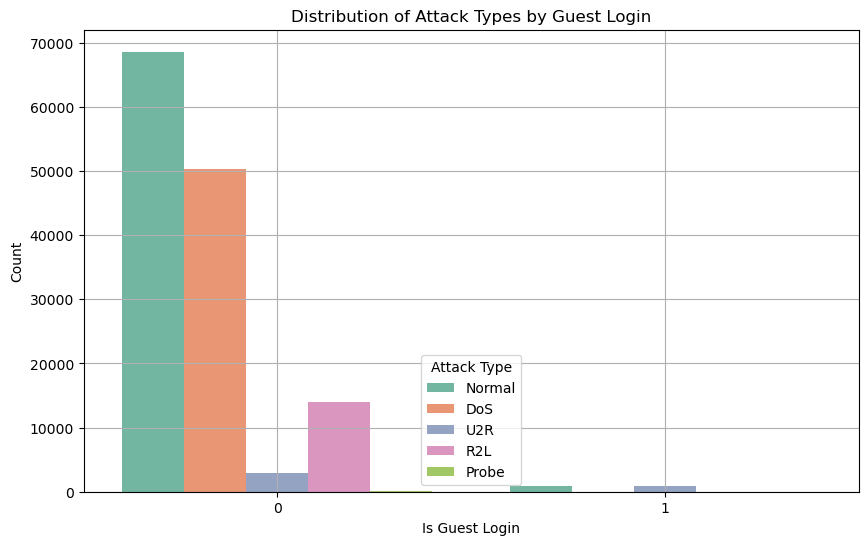

In [74]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_guest_login', hue='attack', data=df1, palette='Set2')
plt.xlabel('Is Guest Login')
plt.ylabel('Count')
plt.title('Distribution of Attack Types by Guest Login')
plt.legend(title='Attack Type')
plt.grid(True)
plt.show()

we can clearly say that attacks are comes when guest is not login

# 5. PREPROCESSING

# 5.1 ENCODING

In [13]:
cat_features = df1.select_dtypes(include='object').columns
cat_features

Index(['protocol_type', 'service', 'flag', 'attack'], dtype='object')

In [14]:
df1['protocol_type'].value_counts()

protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

In [15]:
from sklearn import preprocessing

label_encoders = {}

clm=['protocol_type', 'service', 'flag']
for x in clm:
    le=preprocessing.LabelEncoder()
    le.fit(pd.concat([df1,df2])[x])
    df1[x]=le.transform(df1[x])
    df2[x]=le.transform(df2[x])
    
    label_encoders[x] = le


df1.attack.replace({'Normal': 0, 'DoS':1, 'U2R':2, 'R2L':3, 'Probe':4},inplace=True)
df2.attack.replace({'Normal': 0, 'DoS':1, 'U2R':2, 'R2L':3, 'Probe':4},inplace=True)

In [20]:
df2['attack']

0        1
1        0
2        3
3        3
4        0
        ..
22538    0
22539    0
22540    1
22541    0
22542    3
Name: attack, Length: 22543, dtype: int64

# 5.2 TRAIN-TEST-SPLIT

In [16]:
from sklearn.model_selection import train_test_split

X_train = df1.drop(["attack"], axis=1)
y_train = df1["attack"]

X_test= df2.drop(["attack"], axis=1)
y_test= df2["attack"]

y_train

0         0
1         1
2         0
3         0
4         1
         ..
125967    1
125968    0
125969    0
125970    1
125971    0
Name: attack, Length: 125972, dtype: int64

In [17]:
train_index = X_train.columns
train_index

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

# 5.3 Feature Engineering

In [27]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = train_index
mutual_info.sort_values(ascending=False)

src_bytes                     0.715
service                       0.599
diff_srv_rate                 0.507
flag                          0.502
same_srv_rate                 0.465
dst_bytes                     0.461
dst_host_diff_srv_rate        0.450
dst_host_srv_count            0.418
count                         0.413
dst_host_same_srv_rate        0.402
dst_host_serror_rate          0.400
serror_rate                   0.385
dst_host_srv_serror_rate      0.376
srv_serror_rate               0.358
logged_in                     0.310
level                         0.267
dst_host_srv_diff_host_rate   0.259
dst_host_same_src_port_rate   0.233
dst_host_count                0.210
srv_count                     0.164
srv_diff_host_rate            0.143
dst_host_rerror_rate          0.095
protocol_type                 0.092
dst_host_srv_rerror_rate      0.085
rerror_rate                   0.077
duration                      0.056
srv_rerror_rate               0.054
hot                         

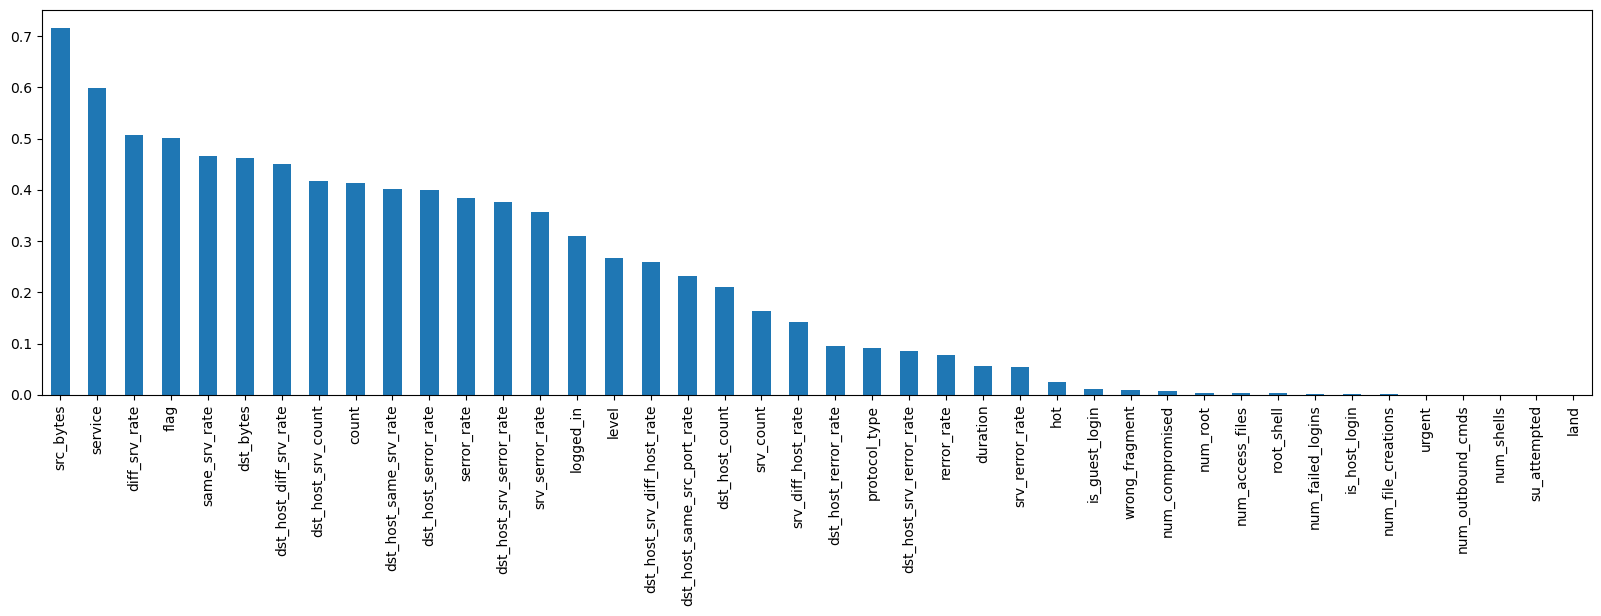

In [28]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));

# 5.4 Feature Selection

In [29]:
from sklearn.feature_selection import SelectKBest
Select_features = SelectKBest(mutual_info_classif, k=30)
Select_features.fit(X_train, y_train)
train_index[Select_features.get_support()]

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'is_guest_login',
       'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

In [18]:
selected_columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised',
       'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate']

X_train=X_train[selected_columns]
X_test=X_test[selected_columns]

# 5.5 Scaling

In [19]:
X_test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,srv_serror_rate,rerror_rate
0,0,1,49,1,0,0,0,0,0,0,136,1,0.000,0.000,1.000
1,2,1,20,9,12983,0,0,0,0,0,1,1,0.000,0.000,0.000
2,0,0,14,9,20,0,0,0,0,0,1,65,0.000,0.000,0.000
3,1,1,60,2,0,15,0,0,0,0,1,8,0.000,0.120,1.000
4,0,1,24,9,267,14515,0,0,1,0,4,4,0.000,0.000,0.000


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

# 6. MODEL BUILD

In [21]:
def evaluvate(X_train, X_test, y_train, y_test):
    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42),
        'Xtream Gradient Boost': xgb.XGBClassifier(n_estimators=100, random_state=42),
        'CatBoost' : CatBoostClassifier(learning_rate=0.1,depth=12,n_estimators=400,l2_leaf_reg=9,random_state=42)
    }
    metrics = {
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Confusion Matrix': []
    }
    best_model = None
    best_accuracy = 0

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        metrics['Accuracy'].append(accuracy)
        metrics['Precision'].append(precision)
        metrics['Recall'].append(recall)
        metrics['F1 Score'].append(f1)
        metrics['Confusion Matrix'].append(cm)

        # Track the best model based on accuracy
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = clf

    for index, classifier_name in enumerate(classifiers.keys()):
        print(f"The {classifier_name} Model Accuracy   = {metrics['Accuracy'][index]:.2f}")
        print(f"The {classifier_name} Model Precision  = {metrics['Precision'][index]:.2f}")
        print(f"The {classifier_name} Model Recall     = {metrics['Recall'][index]:.2f}")
        print(f"The {classifier_name} Model F1 Score   = {metrics['F1 Score'][index]:.2f}")
        print("--------------------------------------------------")

        plt.figure(figsize=(10, 7))
        sns.heatmap(metrics['Confusion Matrix'][index], annot=True, fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f'Confusion Matrix for {classifier_name}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    return best_model  # Returning the best model based on accuracy


Evaluation without Oversampling/Undersampling
0:	learn: 1.2573802	total: 1.62s	remaining: 10m 45s
1:	learn: 1.0364078	total: 2.91s	remaining: 9m 39s
2:	learn: 0.8786022	total: 4.43s	remaining: 9m 46s
3:	learn: 0.7550915	total: 5.77s	remaining: 9m 31s
4:	learn: 0.6586583	total: 7.09s	remaining: 9m 20s
5:	learn: 0.5768880	total: 8.35s	remaining: 9m 8s
6:	learn: 0.5104926	total: 9.52s	remaining: 8m 54s
7:	learn: 0.4546422	total: 10.8s	remaining: 8m 48s
8:	learn: 0.4061793	total: 11.8s	remaining: 8m 32s
9:	learn: 0.3638129	total: 12.6s	remaining: 8m 13s
10:	learn: 0.3271435	total: 13.5s	remaining: 7m 56s
11:	learn: 0.2952512	total: 14.3s	remaining: 7m 41s
12:	learn: 0.2671727	total: 15.3s	remaining: 7m 35s
13:	learn: 0.2420826	total: 16.3s	remaining: 7m 30s
14:	learn: 0.2203128	total: 17.5s	remaining: 7m 27s
15:	learn: 0.2006675	total: 18.7s	remaining: 7m 28s
16:	learn: 0.1826430	total: 19.6s	remaining: 7m 22s
17:	learn: 0.1669353	total: 20.9s	remaining: 7m 23s
18:	learn: 0.1529508	total: 

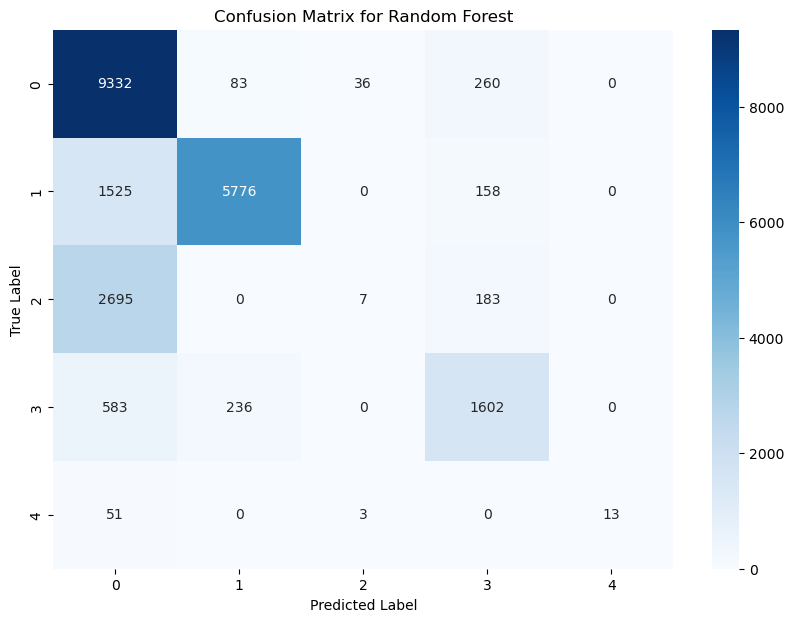

The Xtream Gradient Boost Model Accuracy   = 0.77
The Xtream Gradient Boost Model Precision  = 0.81
The Xtream Gradient Boost Model Recall     = 0.77
The Xtream Gradient Boost Model F1 Score   = 0.72
--------------------------------------------------


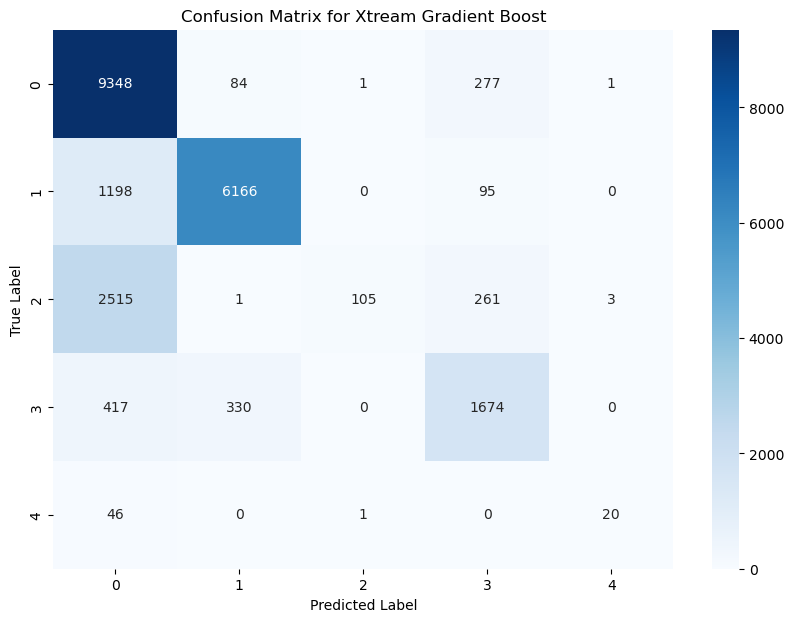

The CatBoost Model Accuracy   = 0.76
The CatBoost Model Precision  = 0.75
The CatBoost Model Recall     = 0.76
The CatBoost Model F1 Score   = 0.72
--------------------------------------------------


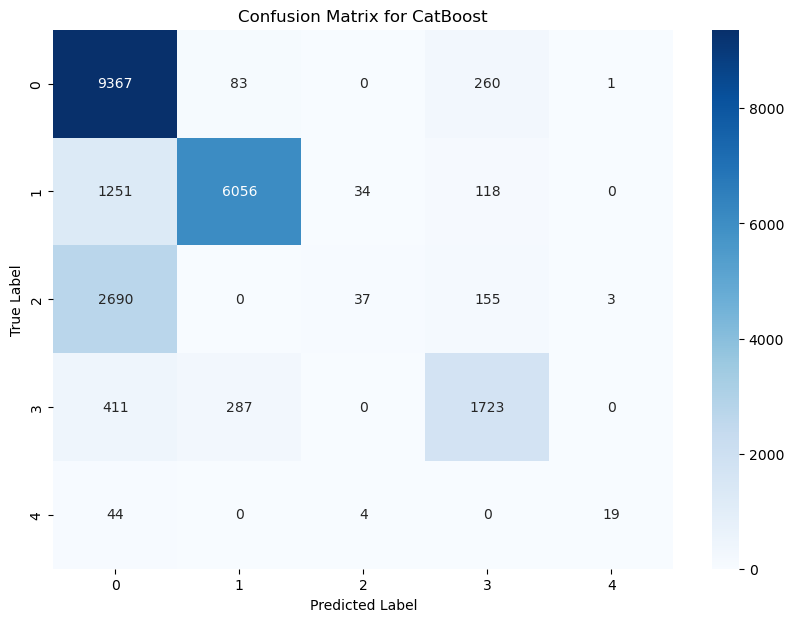

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [34]:
# Evaluate the classifiers
print("Evaluation without Oversampling/Undersampling")
evaluvate(X_train, X_test, y_train, y_test)

# DL classifires

In [88]:
def evaluate_model_with_metrics(model, X_test, y_test_categ):

    # Evaluate model (loss and accuracy)
    loss, accuracy = model.evaluate(X_test, y_test_categ)

    y_pred_probs = model.predict(X_test)

    # Convert probabilities to predicted class labels
    y_pred_labels = y_pred_probs.argmax(axis=1)

    y_test_labels = y_test_categ.argmax(axis=1)

    precision = precision_score(y_test_labels, y_pred_labels, average='weighted')
    recall = recall_score(y_test_labels, y_pred_labels, average='weighted')
    f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')

    report = classification_report(y_test_labels, y_pred_labels)

    print(f"Loss: {loss}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"\nClassification Report:\n{report}")

    cm = confusion_matrix(y_test_labels, y_pred_labels)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0, 1, 2, 3, 4], 
                yticklabels=[0, 1, 2, 3, 4])  # Modify the labels based on your classes
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()


### ANN

In [39]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from keras.utils import to_categorical

y_train_categ = to_categorical(y_train) 
y_test_categ = to_categorical(y_test)

Epoch 1/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9305 - loss: 0.2415 - val_accuracy: 0.9687 - val_loss: 0.0882
Epoch 2/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9704 - loss: 0.0881 - val_accuracy: 0.9740 - val_loss: 0.0725
Epoch 3/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9715 - loss: 0.0766 - val_accuracy: 0.9763 - val_loss: 0.0623
Epoch 4/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9737 - loss: 0.0697 - val_accuracy: 0.9748 - val_loss: 0.0609
Epoch 5/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9745 - loss: 0.0664 - val_accuracy: 0.9761 - val_loss: 0.0585
Epoch 6/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9764 - loss: 0.0599 - val_accuracy: 0.9774 - val_loss: 0.0573
Epoch 7/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9755 - loss: 0.0621 - val_accuracy: 0.9808 - val_loss: 0.0551
Epoch 8/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9772 - loss: 0

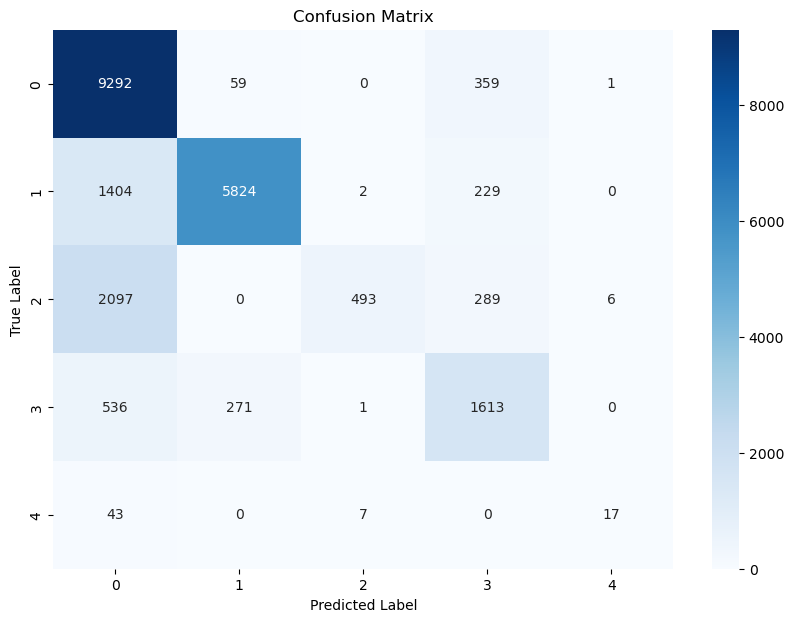

In [40]:

model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu')) 

output_neurons = 5 
model.add(Dense(output_neurons, activation='softmax')) 

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train_categ, epochs=25, batch_size=32, validation_split=0.1)

evaluate_model_with_metrics(model, X_test, y_test_categ)



In [41]:
#CNN
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

Epoch 1/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.8596 - loss: 0.4471 - val_accuracy: 0.9590 - val_loss: 0.1432
Epoch 2/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9409 - loss: 0.1871 - val_accuracy: 0.9638 - val_loss: 0.1114
Epoch 3/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - accuracy: 0.9496 - loss: 0.1616 - val_accuracy: 0.9666 - val_loss: 0.1005
Epoch 4/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - accuracy: 0.9541 - loss: 0.1452 - val_accuracy: 0.9682 - val_loss: 0.0974
Epoch 5/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9564 - loss: 0.1380 - val_accuracy: 0.9686 - val_loss: 0.1003
Epoch 6/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - accuracy: 0.9557 - loss: 0.1371 - val_accuracy: 0.9680 - val_loss: 0.0951
Epoch 7/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - accuracy: 0.9578 - loss: 0.1341 - val_accuracy: 0.9678 - val_loss: 0.0965
Epoch 8/25
3543/3543 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9590 - 

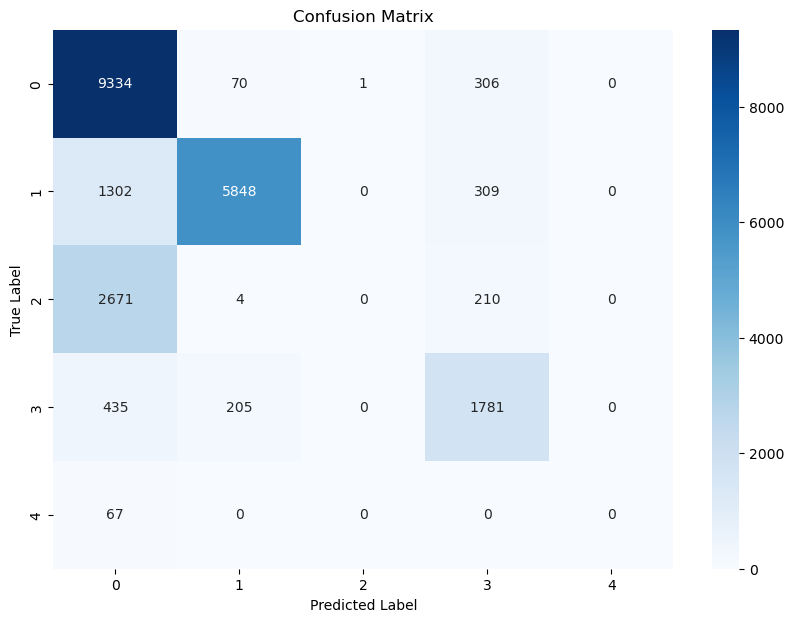

In [42]:
# Create the CNN model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))

model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_categ.shape[1], activation='softmax'))  # Output layer for multi-class classification

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train_categ, epochs=25, batch_size=32, validation_split=0.1)

# Evaluate the model on the test data
evaluate_model_with_metrics(model, X_test, y_test_categ)

Epoch 1/25
3543/3543 [==============================] - 19s 5ms/step - loss: 0.0872 - accuracy: 0.9759 - val_loss: 0.0169 - val_accuracy: 0.9947
Epoch 2/25
3543/3543 [==============================] - 17s 5ms/step - loss: 0.0352 - accuracy: 0.9914 - val_loss: 0.0119 - val_accuracy: 0.9954
Epoch 3/25
3543/3543 [==============================] - 18s 5ms/step - loss: 0.0267 - accuracy: 0.9929 - val_loss: 0.0092 - val_accuracy: 0.9967
Epoch 4/25
3543/3543 [==============================] - 17s 5ms/step - loss: 0.0242 - accuracy: 0.9938 - val_loss: 0.0093 - val_accuracy: 0.9962
Epoch 5/25
3543/3543 [==============================] - 17s 5ms/step - loss: 0.0221 - accuracy: 0.9943 - val_loss: 0.0075 - val_accuracy: 0.9974
Epoch 6/25
3543/3543 [==============================] - 18s 5ms/step - loss: 0.0183 - accuracy: 0.9948 - val_loss: 0.0071 - val_accuracy: 0.9974
Epoch 7/25
3543/3543 [==============================] - 19s 5ms/step - loss: 0.0181 - accuracy: 0.9950 - val_loss: 0.0074 - val_ac

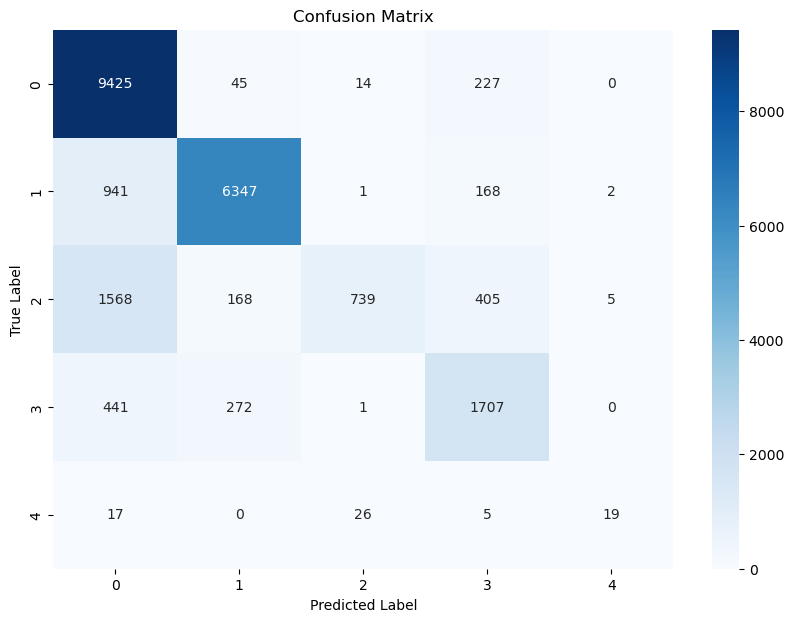

In [ ]:
#MLPC
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))  # Input layer
model.add(Dropout(0.5))  # Dropout layer to reduce overfitting
model.add(Dense(64, activation='relu'))  # Hidden layer
model.add(Dropout(0.5))  # Dropout layer to reduce overfitting
model.add(Dense(y_train_categ.shape[1], activation='softmax'))  # Output layer for multi-class classification

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train_categ, epochs=25, batch_size=32, validation_split=0.1)

# Evaluate the model on the test data
evaluate_model_with_metrics(model, X_test, y_test_categ)

# 7 Sampling Techniques

In [74]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pandas as pd

total_train_samples = 125972  

target_ratios = {
    0: 0.5164,  # Normal
    1: 0.3934,  # DoS
    2: 0.1540,  # U2R
    3: 0.1285,  # R2L
    4: 0.0035   # Probe
}

target_counts = {attack: int(total_train_samples * ratio) for attack, ratio in target_ratios.items()}

current_counts = pd.Series(y_train).value_counts().to_dict()

oversample_counts = {attack: target_counts[attack] for attack in target_counts if current_counts.get(attack, 0) < target_counts[attack]}

if oversample_counts:
    smote = SMOTE(sampling_strategy=oversample_counts, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print("After SMOTE - Counts:", pd.Series(y_resampled).value_counts())
else:
    X_resampled, y_resampled = X_train, y_train

resampled_counts = pd.Series(y_resampled).value_counts()
undersample_counts = {attack: target_counts[attack] for attack in target_counts if resampled_counts.get(attack, 0) > target_counts[attack]}

if undersample_counts:
    nearmiss = NearMiss(sampling_strategy=undersample_counts, version=1)  # or version=3 for more control
    X_final, y_final = nearmiss.fit_resample(X_resampled, y_resampled)
    print("Final Counts after NearMiss Undersampling:", pd.Series(y_final).value_counts())
else:
    X_final, y_final = X_resampled, y_resampled

After SMOTE - Counts: attack
0    69494
1    50271
2    19399
3    16187
4      440
Name: count, dtype: int64
Final Counts after NearMiss Undersampling: attack
0    65051
1    49557
2    19399
3    16187
4      440
Name: count, dtype: int64


In [75]:
print(X_final.shape,X_test.shape,y_final.shape,y_test.shape)

(150634, 15) (22543, 15) (150634,) (22543,)


0:	learn: 1.2818117	total: 1.67s	remaining: 11m 6s
1:	learn: 1.0755550	total: 3.36s	remaining: 11m 8s
2:	learn: 0.9241006	total: 5.01s	remaining: 11m 3s
3:	learn: 0.8077038	total: 6.58s	remaining: 10m 51s
4:	learn: 0.7133172	total: 7.99s	remaining: 10m 31s
5:	learn: 0.6355906	total: 9.59s	remaining: 10m 29s
6:	learn: 0.5679824	total: 10.9s	remaining: 10m 14s
7:	learn: 0.5123360	total: 12.3s	remaining: 10m
8:	learn: 0.4646705	total: 13.7s	remaining: 9m 53s
9:	learn: 0.4216691	total: 15s	remaining: 9m 43s
10:	learn: 0.3848136	total: 16.4s	remaining: 9m 38s
11:	learn: 0.3523842	total: 17.6s	remaining: 9m 29s
12:	learn: 0.3242738	total: 19s	remaining: 9m 26s
13:	learn: 0.2994085	total: 20.5s	remaining: 9m 24s
14:	learn: 0.2776184	total: 21.8s	remaining: 9m 20s
15:	learn: 0.2570847	total: 23.1s	remaining: 9m 13s
16:	learn: 0.2387343	total: 24.3s	remaining: 9m 6s
17:	learn: 0.2229267	total: 25.7s	remaining: 9m 4s
18:	learn: 0.2087382	total: 27s	remaining: 9m 2s
19:	learn: 0.1956024	total: 28

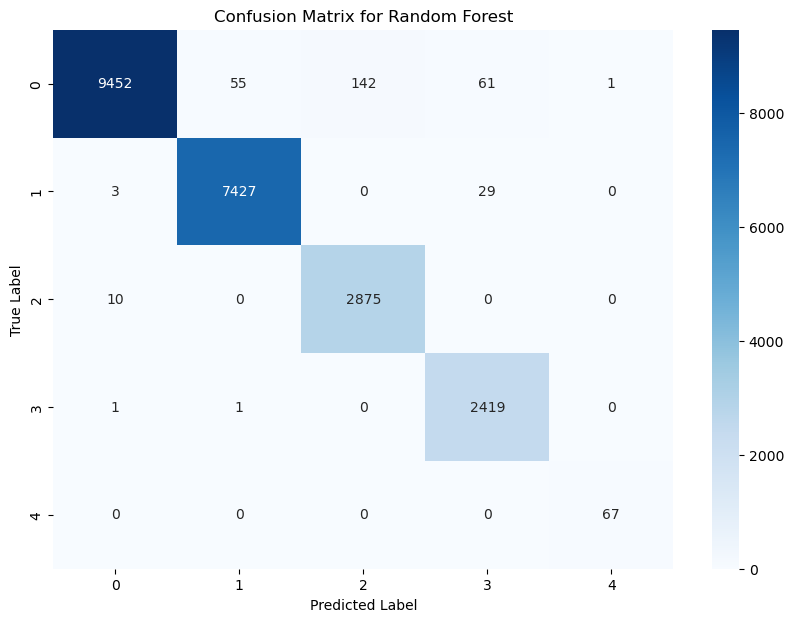

The Xtream Gradient Boost Model Accuracy   = 0.98
The Xtream Gradient Boost Model Precision  = 0.98
The Xtream Gradient Boost Model Recall     = 0.98
The Xtream Gradient Boost Model F1 Score   = 0.98
--------------------------------------------------


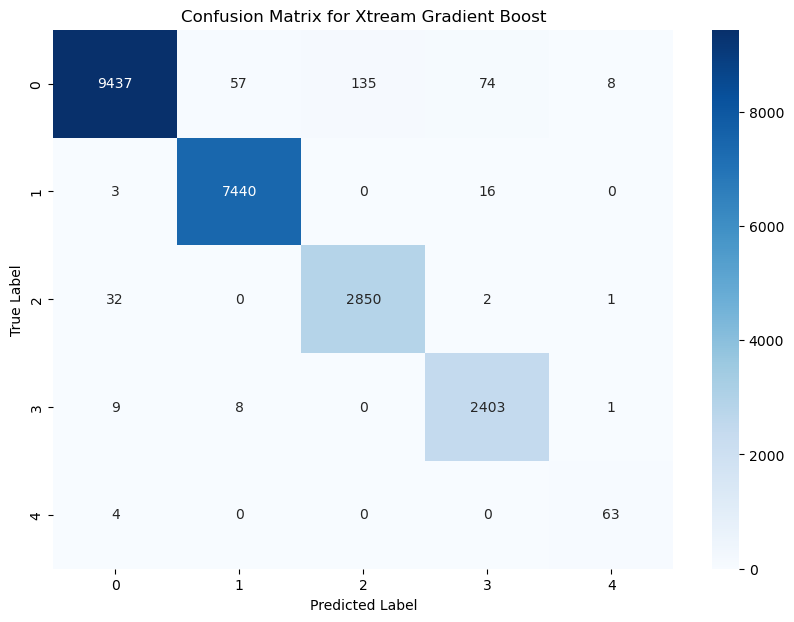

The CatBoost Model Accuracy   = 0.98
The CatBoost Model Precision  = 0.98
The CatBoost Model Recall     = 0.98
The CatBoost Model F1 Score   = 0.98
--------------------------------------------------


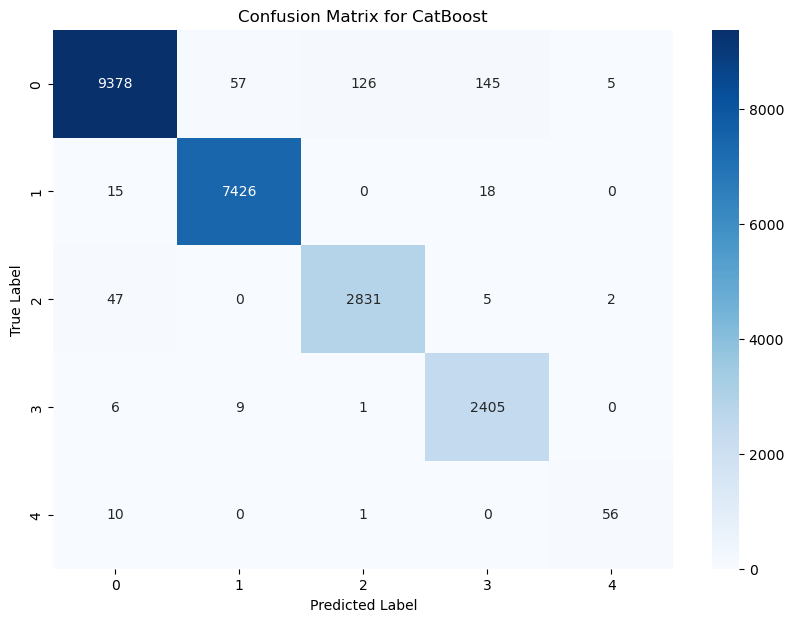

In [76]:
best_model=evaluvate(X_final, X_test, y_final,y_test)

In [22]:
import joblib

In [23]:
# Load the saved LabelEncoders
label_encoders = joblib.load('label_encoders.pkl')

# Load the saved scaler
scaler_loaded = joblib.load('scaler.pkl')

rf_model=joblib.load('rf_model.pkl')

# Sample input with categorical values
input_data = [0	,'udp',	'other',	'SF'	,146,	0,	0,	0,	0	,0	,13,	1,	0.000,	0.000,	0.000]

# Apply label encoding for categorical features
input_data[1] = label_encoders['protocol_type'].transform([input_data[1]])[0]
input_data[2] = label_encoders['service'].transform([input_data[2]])[0]
input_data[3] = label_encoders['flag'].transform([input_data[3]])[0]

input_data = np.array(input_data)

# Reshape input to be 2D because scaler expects (n_samples, n_features)
input_data = input_data.reshape(1, -1)

# Apply scaling
scaled_input = scaler_loaded.transform(input_data)


print("scaled_input: ",scaled_input)
prediction=rf_model.predict(scaled_input)
classes=['Normal','Dos','U2R','R2L','Probe']
prediction=classes[prediction[0]]
print("prediction: ",prediction)



scaled_input:  [[-0.11024967  2.21930219  0.78142044  0.75111595 -0.0077374  -0.00491866
  -0.08948678 -0.09507605 -0.80926713 -0.01166369 -0.62098696 -0.36811175
  -0.63721282 -0.63193254 -0.37436393]]
prediction:  R2L


In [ ]:
#import joblib

#joblib.dump(label_encoders, 'label_encoders.pkl')

#joblib.dump(scaler, 'scaler.pkl')

#joblib.dump(best_model, 'rf_model.pkl')



['scaler.pkl']

In [69]:
X_test

array([[-0.11679106, -0.13286666,  1.04669028, ..., -0.61493583,
        -0.6100268 ,  2.59406773],
       [-0.1160077 , -0.13286666, -0.70818364, ..., -0.61493583,
        -0.6100268 , -0.39873673],
       [-0.11679106, -2.43334606, -1.071261  , ..., -0.61493583,
        -0.6100268 , -0.39873673],
       ...,
       [-0.11679106, -0.13286666, -0.46613207, ..., -0.61493583,
        -0.6100268 , -0.39873673],
       [-0.11679106,  2.16761274, -1.19228679, ..., -0.61493583,
        -0.6100268 , -0.39873673],
       [-0.11679106, -0.13286666,  1.53079343, ..., -0.61493583,
        -0.6100268 ,  2.59406773]])

Epoch 1/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8793 - loss: 0.3248 - val_accuracy: 0.4514 - val_loss: 1.7230
Epoch 2/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9412 - loss: 0.1422 - val_accuracy: 0.3529 - val_loss: 2.3480
Epoch 3/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9446 - loss: 0.1312 - val_accuracy: 0.5046 - val_loss: 2.1123
Epoch 4/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9465 - loss: 0.1241 - val_accuracy: 0.5892 - val_loss: 1.9834
Epoch 5/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9471 - loss: 0.1225 - val_accuracy: 0.5638 - val_loss: 2.4649
Epoch 6/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9494 - loss: 0.1174 - val_accuracy: 0.6659 - val_loss: 2.4079
Epoch 7/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.9501 - loss: 0.1144 - val_accuracy: 0.6288 - val_loss: 2.3849
Epoch 8/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9509 - loss: 0

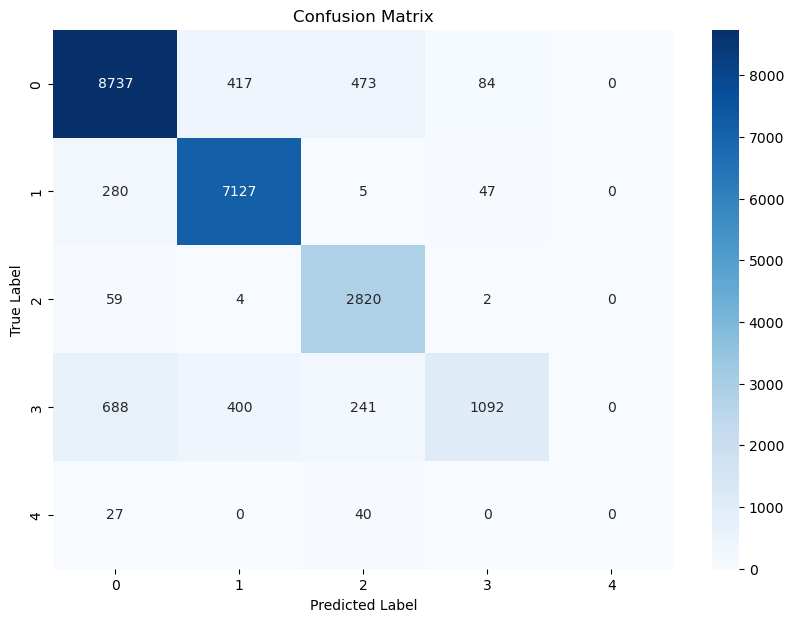

Epoch 1/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.8038 - loss: 0.5169 - val_accuracy: 0.1387 - val_loss: 2.4834
Epoch 2/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.8842 - loss: 0.2745 - val_accuracy: 0.1175 - val_loss: 2.4775
Epoch 3/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.9018 - loss: 0.2316 - val_accuracy: 0.2598 - val_loss: 2.2870
Epoch 4/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - accuracy: 0.9109 - loss: 0.2174 - val_accuracy: 0.2409 - val_loss: 2.4551
Epoch 5/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.9137 - loss: 0.2082 - val_accuracy: 0.1822 - val_loss: 2.5975
Epoch 6/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9176 - loss: 0.2011 - val_accuracy: 0.2052 - val_loss: 2.4161
Epoch 7/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9190 - loss: 0.1974 - val_accuracy: 0.2227 - val_loss: 2.5456
Epoch 8/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9217 - loss: 0

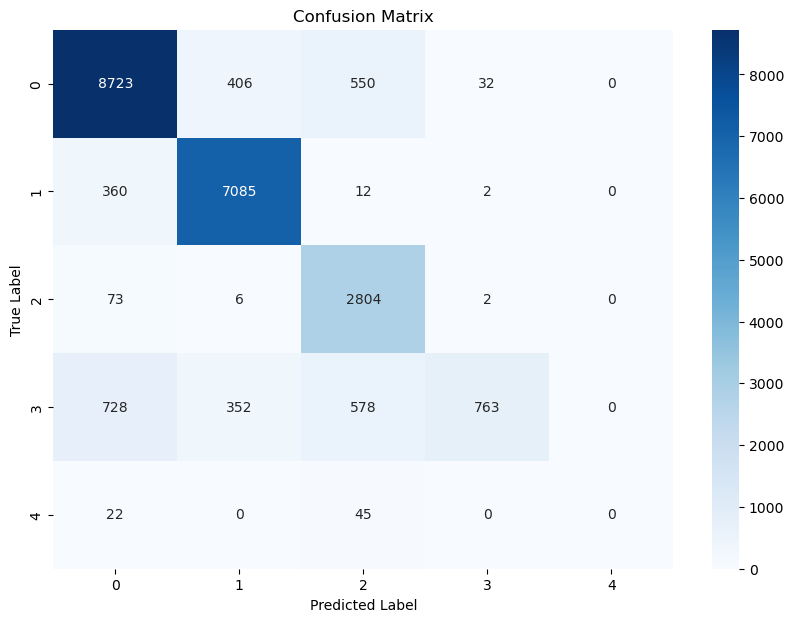

Epoch 1/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8447 - loss: 0.4275 - val_accuracy: 0.2050 - val_loss: 2.4903
Epoch 2/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9168 - loss: 0.2180 - val_accuracy: 0.3041 - val_loss: 2.5310
Epoch 3/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9260 - loss: 0.1856 - val_accuracy: 0.3702 - val_loss: 2.9415
Epoch 4/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9311 - loss: 0.1724 - val_accuracy: 0.4811 - val_loss: 2.8697
Epoch 5/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9342 - loss: 0.1603 - val_accuracy: 0.4015 - val_loss: 3.0315
Epoch 6/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9350 - loss: 0.1606 - val_accuracy: 0.4864 - val_loss: 3.2657
Epoch 7/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9361 - loss: 0.1569 - val_accuracy: 0.5139 - val_loss: 3.4101
Epoch 8/25
4237/4237 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9375 - loss: 0

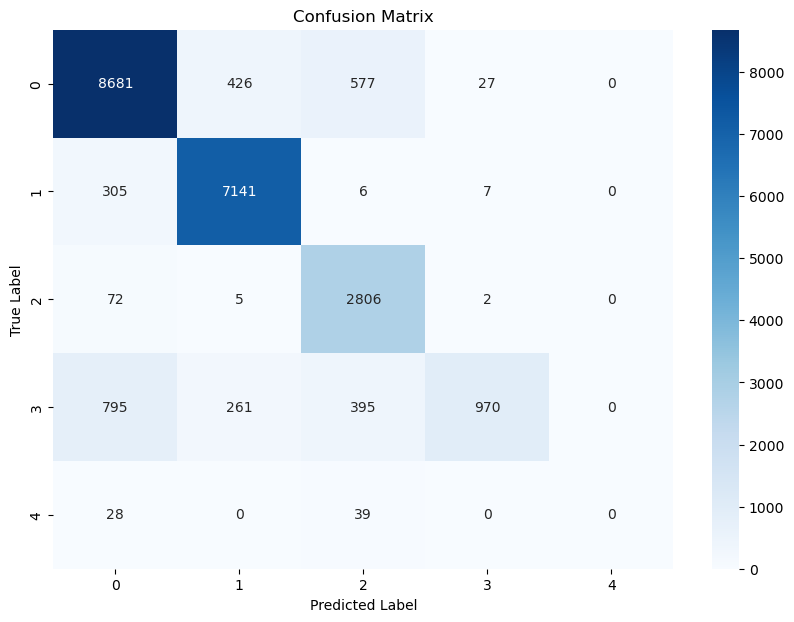

In [89]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from keras.utils import to_categorical
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert y_final to categorical format
y_final_categ = to_categorical(y_final)
y_test_categ = to_categorical(y_test)

# ANN Model
model = Sequential()
model.add(Dense(64, input_dim=X_final.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))

output_neurons = y_final_categ.shape[1]  # Number of output classes
model.add(Dense(output_neurons, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model on X_final and y_final
model.fit(X_final, y_final_categ, epochs=25, batch_size=32, validation_split=0.1)

# Evaluate the model on X_test and y_test
loss, accuracy = model.evaluate(X_test, y_test_categ)

print("ANN REPORT")
evaluate_model_with_metrics(model,X_test,y_test_categ)

# CNN Model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_final.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))

model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_final_categ.shape[1], activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the CNN model on X_final and y_final
model.fit(X_final, y_final_categ, epochs=25, batch_size=32, validation_split=0.1)

# Evaluate the model on X_test and y_test

print("CNN REPORT")
evaluate_model_with_metrics(model,X_test,y_test_categ)



# MLPC Model
model = Sequential()
model.add(Dense(128, input_dim=X_final.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_final_categ.shape[1], activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the MLPC model on X_final and y_final
model.fit(X_final, y_final_categ, epochs=25, batch_size=32, validation_split=0.1)


print("MLPC REPORT")
evaluate_model_with_metrics(model,X_test,y_test_categ)



In [36]:
d=pd.read_csv('../input/nsl-kdd/KDDTrain+.txt' , names=columns)

d = d[selected_columns]

d.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,srv_serror_rate,rerror_rate
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,2,2,0.000,0.000,0.000
1,0,udp,other,SF,146,0,0,0,0,0,13,1,0.000,0.000,0.000
2,0,tcp,private,S0,0,0,0,0,0,0,123,6,1.000,1.000,0.000
3,0,tcp,http,SF,232,8153,0,0,1,0,5,5,0.200,0.200,0.000
4,0,tcp,http,SF,199,420,0,0,1,0,30,32,0.000,0.000,0.000
